
<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2e75b6 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
<h1 style="font-size: 2.5em; margin-bottom: 10px;">🧹 Olist E-Commerce</h1>
<h2 style="font-weight: 300; font-size: 1.5em; margin-bottom: 20px;">Data Cleaning Notebook</h2>
<p style="font-size: 1.1em; opacity: 0.85;" >Step 3 of 6 · integration → EDA → <b>Cleaning</b> → Feature Engineering → Preprocessing → Modeling</p>
</div>

---

## What This Notebook Does

| Step | Action | Reason |
|---|---|---|
| **1** | Imports & load data | Start fresh from merged CSV |
| **2** | Snapshot before cleaning | Know what we started with |
| **3** | Filter to delivered orders | Non-delivered have no review/delivery date |
| **4** | Drop high-missing columns | 58–88% missing, not usable |
| **5** | Drop missing delivery dates | True data quality errors post-filter |
| **6** | Drop missing review scores | Can't model without the target |
| **7** | Impute product dimensions | Category-level median — smarter than global |
| **8** | Fill missing categories | Replace with 'unknown' |
| **9** | Drop remaining null rows | Payment, seller, price — very few |
| **10** | Cap price/freight outliers | Prevent extreme values from distorting models |
| **11** | Validate & save | Final check + export clean CSV |


## Step 1 — Imports & Load Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('olist_merged.csv')

# Parse date columns
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Loaded: 119,143 rows × 40 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares


## Step 2 — Snapshot Before Cleaning

Before touching anything, we record the baseline so we can track exactly how many rows and columns are removed at each step.


  BASELINE SNAPSHOT
  Rows:        119,143
  Columns:     40
  Duplicates:  0
  Date range:  2016-09-04 → 2018-10-17


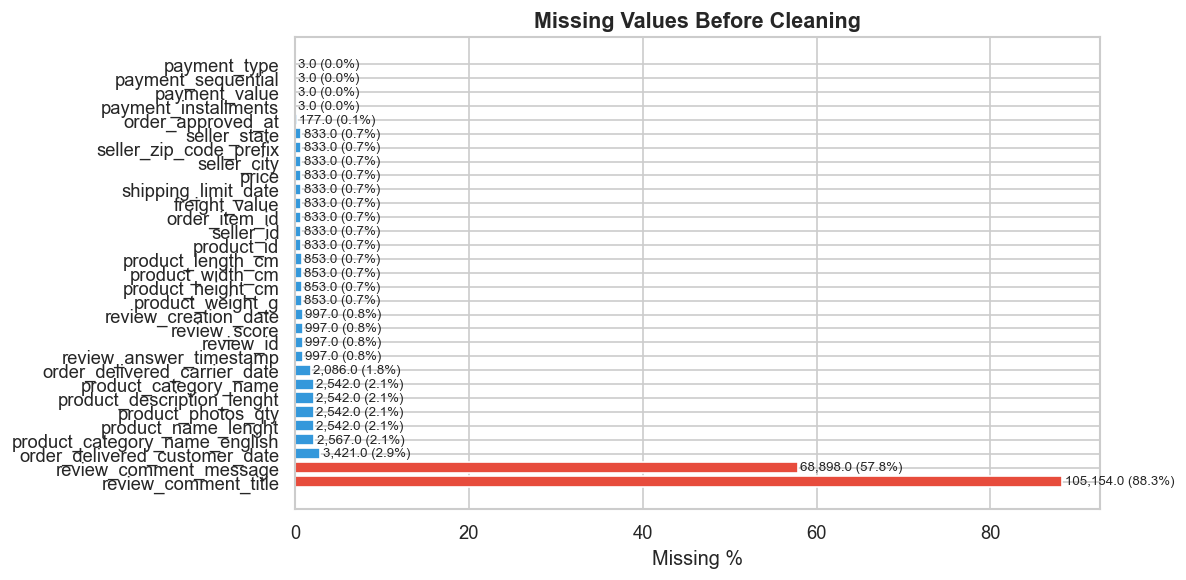

                               missing_count  missing_pct
review_comment_title                  105154        88.26
review_comment_message                 68898        57.83
order_delivered_customer_date           3421         2.87
product_category_name_english           2567         2.15
product_name_lenght                     2542         2.13
product_photos_qty                      2542         2.13
product_description_lenght              2542         2.13
product_category_name                   2542         2.13
order_delivered_carrier_date            2086         1.75
review_answer_timestamp                  997         0.84
review_id                                997         0.84
review_score                             997         0.84
review_creation_date                     997         0.84
product_weight_g                         853         0.72
product_height_cm                        853         0.72
product_width_cm                         853         0.72
product_length

In [17]:
# Baseline snapshot
print("=" * 55)
print(f"  BASELINE SNAPSHOT")
print("=" * 55)
print(f"  Rows:        {len(df):,}")
print(f"  Columns:     {df.shape[1]}")
print(f"  Duplicates:  {df.duplicated().sum():,}")
print(f"  Date range:  {df['order_purchase_timestamp'].min().date()} "
      f"→ {df['order_purchase_timestamp'].max().date()}")
print("=" * 55)

# Null summary
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'missing_count': nulls, 'missing_pct': null_pct})
null_df = null_df[null_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db'
          for p in null_df['missing_pct']]
ax.barh(null_df.index, null_df['missing_pct'], color=colors, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values Before Cleaning', fontsize=13, fontweight='bold')
for i, (idx, row) in enumerate(null_df.iterrows()):
    ax.text(row['missing_pct'] + 0.3, i,
            f"{row['missing_count']:,} ({row['missing_pct']:.1f}%)",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(null_df.to_string())

## Step 3 — Filter to Delivered Orders

**Why:** Non-delivered orders (cancelled, shipped-in-progress, unavailable) have no `order_delivered_customer_date` or `review_score` — the two most important columns for modeling. Keeping them would add noise and structural nulls we can't impute.

| Status | Count | Action |
|---|---|---|
| delivered | 115,723 | ✅ Keep |
| shipped | 1,256 | ❌ Remove |
| canceled | 750 | ❌ Remove |
| unavailable | 652 | ❌ Remove |
| others | ~760 | ❌ Remove |


In [18]:
before = len(df)
print("Order status distribution BEFORE filter:")
print(df['order_status'].value_counts().to_string())

df_clean = df[df['order_status'] == 'delivered'].copy()

print(f"\n{'='*45}")
print(f"  Rows removed:  {before - len(df_clean):,}")
print(f"  Rows kept:     {len(df_clean):,}")
print(f"  Retention:     {len(df_clean)/before*100:.1f}%")
print(f"{'='*45}")

Order status distribution BEFORE filter:
order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3

  Rows removed:  3,420
  Rows kept:     115,723
  Retention:     97.1%


## Step 4 — Drop High-Missing Columns

`review_comment_title` (88% missing) and `review_comment_message` (58% missing) are optional free-text fields. They would require NLP to use and are too sparse to be meaningful features in a tabular ML model.


In [19]:
cols_to_drop = ['review_comment_title', 'review_comment_message']

for col in cols_to_drop:
    missing_pct = df_clean[col].isnull().mean() * 100
    print(f"Dropping '{col}': {missing_pct:.1f}% missing")

df_clean = df_clean.drop(columns=cols_to_drop)

print(f"\nColumns remaining: {df_clean.shape[1]}")

Dropping 'review_comment_title': 88.3% missing
Dropping 'review_comment_message': 58.4% missing

Columns remaining: 38


## Step 5 — Drop Rows with Missing Delivery Dates

After filtering to `delivered` orders, any remaining null in `order_delivered_customer_date` or `order_delivered_carrier_date` is a **true data quality error** — a delivered order must have a delivery date. These are not structurally expected nulls; they are bad records.


In [20]:
before = len(df_clean)

# Check how many remain after the delivered filter
print("Remaining nulls in delivery date columns:")
print(f"  order_delivered_customer_date:  "
      f"{df_clean['order_delivered_customer_date'].isnull().sum():,}")
print(f"  order_delivered_carrier_date:   "
      f"{df_clean['order_delivered_carrier_date'].isnull().sum():,}")

df_clean = df_clean.dropna(
    subset=['order_delivered_customer_date', 'order_delivered_carrier_date']
)

print(f"\nRows removed: {before - len(df_clean):,}")
print(f"Rows remaining: {len(df_clean):,}")

Remaining nulls in delivery date columns:
  order_delivered_customer_date:  8
  order_delivered_carrier_date:   2

Rows removed: 9
Rows remaining: 115,714


## Step 6 — Drop Rows with Missing Review Score

`review_score` is our **target variable**. Rows without it cannot be used for supervised learning and must be dropped.


In [21]:
before = len(df_clean)

print(f"Missing review scores: {df_clean['review_score'].isnull().sum():,}")

df_clean = df_clean.dropna(subset=['review_score'])

print(f"Rows removed: {before - len(df_clean):,}")
print(f"Rows remaining: {len(df_clean):,}")
print(f"\nReview score distribution after drop:")
print(df_clean['review_score'].value_counts().sort_index().to_string())

Missing review scores: 861
Rows removed: 861
Rows remaining: 114,853

Review score distribution after drop:
review_score
1.0    13117
2.0     3899
3.0     9649
4.0    22150
5.0    66038


## Step 7 — Impute Product Dimensions

Product dimension and weight nulls (~850 rows) are **not random** — they tend to cluster in certain categories. Using the **category-level median** is smarter than the global median because a heavy furniture item shouldn't be imputed with the average weight of all products across 73 categories.

**Strategy:** Fill with category median → fallback to global median for any remaining nulls (rows with no category).


In [22]:
dim_cols = [
    'product_weight_g', 'product_length_cm', 'product_height_cm',
    'product_width_cm', 'product_name_lenght', 'product_description_lenght',
    'product_photos_qty'
]

print("Nulls BEFORE imputation:")
for col in dim_cols:
    n = df_clean[col].isnull().sum()
    if n > 0:
        print(f"  {col}: {n:,}")

for col in dim_cols:
    # Category-level median
    cat_median = df_clean.groupby('product_category_name_english')[col].transform('median')
    df_clean[col] = df_clean[col].fillna(cat_median)
    # Global median fallback
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nNulls AFTER imputation:")
remaining = df_clean[dim_cols].isnull().sum()
print(remaining[remaining > 0].to_string() if remaining.sum() > 0 else "  ✅ None remaining")

Nulls BEFORE imputation:
  product_weight_g: 20
  product_length_cm: 20
  product_height_cm: 20
  product_width_cm: 20
  product_name_lenght: 1,626
  product_description_lenght: 1,626
  product_photos_qty: 1,626

Nulls AFTER imputation:
  ✅ None remaining


## Step 8 — Fill Missing Product Categories

A small number of rows have no `product_category_name_english`. Rather than dropping them, we label them `'unknown'` — this preserves the rows and the model can learn that unknown-category products may behave differently.


In [23]:
for col in ['product_category_name_english', 'product_category_name']:
    n_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna('unknown')
    print(f"'{col}': filled {n_missing:,} nulls with 'unknown'")

'product_category_name_english': filled 1,649 nulls with 'unknown'
'product_category_name': filled 1,626 nulls with 'unknown'


## Step 9 — Drop Remaining Null Rows

A small number of rows still have nulls in payment, seller, or price columns. These are few enough to drop without meaningful data loss.


In [24]:
before = len(df_clean)

critical_cols = ['payment_type', 'payment_value', 'price', 'freight_value', 'seller_id']

print("Remaining nulls in critical columns:")
for col in critical_cols:
    n = df_clean[col].isnull().sum()
    print(f"  {col}: {n:,}")

df_clean = df_clean.dropna(subset=critical_cols)

print(f"\nRows removed: {before - len(df_clean):,}")
print(f"Rows remaining: {len(df_clean):,}")

Remaining nulls in critical columns:
  payment_type: 3
  payment_value: 3
  price: 0
  freight_value: 0
  seller_id: 0

Rows removed: 3
Rows remaining: 114,850


## Step 10 — Cap Price & Freight Outliers

The EDA showed extreme outliers in price (max R$6,735), freight (max R$409), and payment value. We **cap** at the 99.5th percentile rather than drop — this preserves the rows while preventing extreme values from distorting model training.

**Why cap and not drop?** These are real transactions. A R$5,000 order is valid data; we just don't want it to dominate the loss function.


price: capped 563 rows at 1200.00 (was 6735.00)
freight_value: capped 575 rows at 105.11 (was 409.68)
payment_value: capped 572 rows at 1591.24 (was 13664.08)


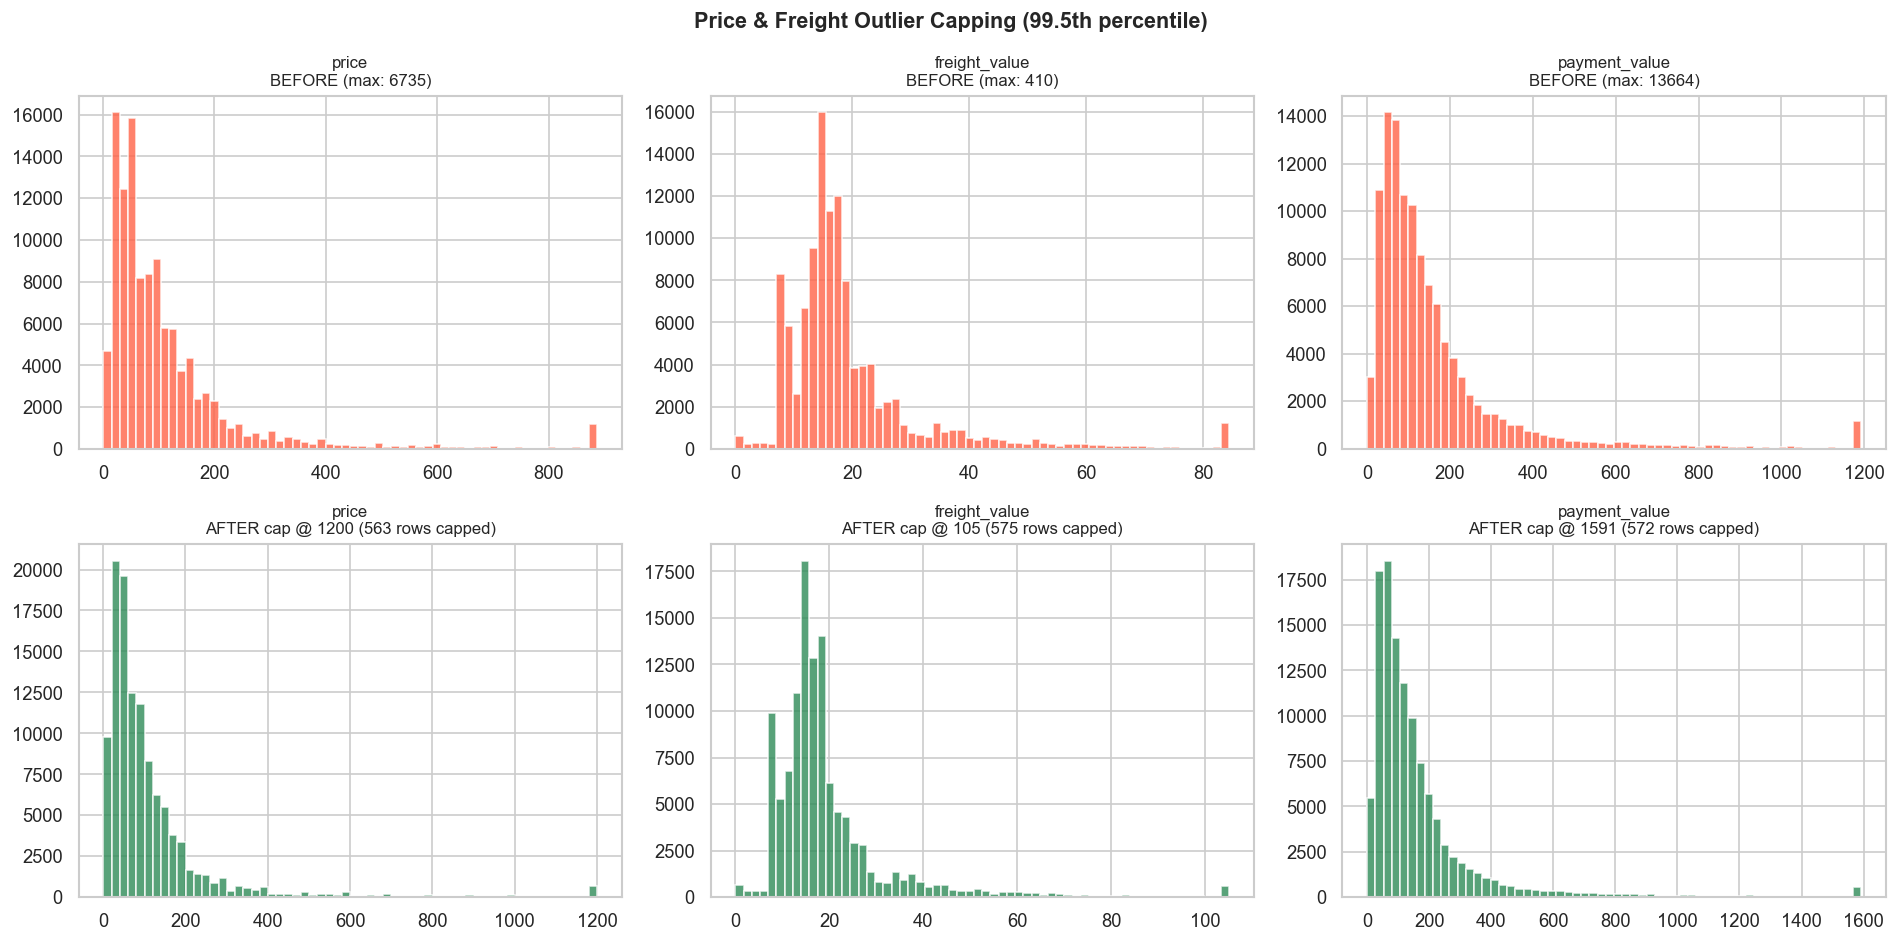

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cap_cols = ['price', 'freight_value', 'payment_value']

for i, col in enumerate(cap_cols):
    cap = df_clean[col].quantile(0.995)
    before_max = df_clean[col].max()
    n_capped = (df_clean[col] > cap).sum()

    # Before
    axes[0, i].hist(df_clean[col].clip(upper=df_clean[col].quantile(0.99)),
                    bins=60, color='tomato', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\nBEFORE (max: {before_max:.0f})', fontsize=10)

    # Apply cap
    df_clean[col] = df_clean[col].clip(upper=cap)

    # After
    axes[1, i].hist(df_clean[col], bins=60, color='seagreen', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\nAFTER cap @ {cap:.0f} ({n_capped:,} rows capped)', fontsize=10)

    print(f"{col}: capped {n_capped:,} rows at {cap:.2f} (was {before_max:.2f})")

plt.suptitle('Price & Freight Outlier Capping (99.5th percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11 — Validate & Save

Final check: confirm no nulls remain in critical columns, review the before/after summary, and export the clean dataset.


  FINAL NULL CHECK
order_approved_at    15

  CLEANING SUMMARY
  Rows before:   119,143
  Rows after:    114,850
  Rows removed:  4,293 (3.6%)
  Cols before:   40
  Cols after:    38
  Cols removed:  2


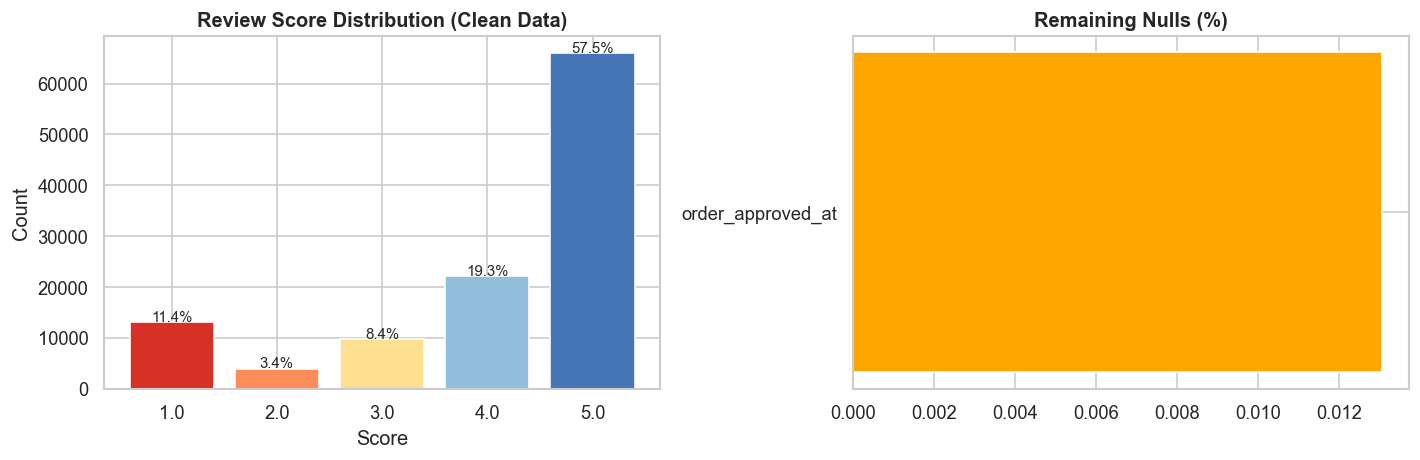

In [26]:
# ── Final null check ──────────────────────────────────────────────────────────
print("=" * 55)
print("  FINAL NULL CHECK")
print("=" * 55)
remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("  No nulls in any column")
else:
    print(remaining_nulls.to_string())

# ── Before vs after summary ────────────────────────────────────────────────────
print()
print("=" * 55)
print("  CLEANING SUMMARY")
print("=" * 55)
print(f"  Rows before:   {len(df):,}")
print(f"  Rows after:    {len(df_clean):,}")
print(f"  Rows removed:  {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")
print(f"  Cols before:   {df.shape[1]}")
print(f"  Cols after:    {df_clean.shape[1]}")
print(f"  Cols removed:  {df.shape[1] - df_clean.shape[1]}")
print("=" * 55)

# ── Review score distribution in clean data ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

score_counts = df_clean['review_score'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
axes[0].bar(score_counts.index.astype(str), score_counts.values, color=colors)
axes[0].set_title('Review Score Distribution (Clean Data)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(score_counts.items()):
    axes[0].text(i, v + 200, f"{v/score_counts.sum()*100:.1f}%",
                 ha='center', fontsize=9)

# Remaining nulls heatmap
null_pct_clean = (df_clean.isnull().sum() / len(df_clean) * 100)
null_pct_clean = null_pct_clean[null_pct_clean > 0]
if len(null_pct_clean) > 0:
    axes[1].barh(null_pct_clean.index, null_pct_clean.values, color='orange')
    axes[1].set_title('Remaining Nulls (%)', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, '✅ Zero nulls\nin critical columns',
                 ha='center', va='center', fontsize=14, color='green',
                 transform=axes[1].transAxes)
    axes[1].set_title('Null Check', fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
# ── Save clean dataset ────────────────────────────────────────────────────────
df_clean.to_csv('olist_clean.csv', index=False)
print("Saved: olist_clean.csv")
print(f"Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\n📌 Next step: Feature Engineering notebook (olist_clean.csv → olist_features.csv)")

Saved: olist_clean.csv
Shape: 114,850 rows × 38 columns

📌 Next step: Feature Engineering notebook (olist_clean.csv → olist_features.csv)
